#  Pure Premium Pricing Framework

## Executive Overview

The objective of an insurance pricing model is to estimate the **expected future claim cost** for every insured policy.

Rather than predicting aggregate losses directly, actuarial pricing frameworks decompose the expected loss into two independent components:

- Claim Frequency
- Claim Severity

The expected annual loss, commonly referred to as the **Pure Premium**, is calculated as

\[
E(L)=E(N)\times E(S)
\]

where:

- \(E(N)\) represents the expected claim frequency.
- \(E(S)\) represents the expected claim severity.

This decomposition enables insurers to model claim occurrence and claim cost separately using statistical methods tailored to each process.

The objective of this notebook is to integrate the independently developed frequency and severity models into a unified pricing framework and evaluate multiple candidate pricing engines.

# 1. Import Required Libraries

This notebook relies on the scientific Python ecosystem for data manipulation, statistical analysis, visualization, and model evaluation.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")

pd.set_option("display.max_columns", None)

# 2. Load Prediction Artifacts

To ensure a modular and reproducible workflow, each modeling notebook exported its predictions as standalone CSV files.

These prediction artifacts are now imported and will serve as the inputs to the pricing engine.

This separation of model development and model integration reflects common practices in production machine learning systems.

In [4]:
from pathlib import Path

prediction_path = Path(r"C:\Users\Umer\predictions")

In [6]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
C:\Users\Umer


In [7]:
import os

print(os.listdir())

['.anaconda', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '05_xgboost_frequency_model.ipynb.ipynb', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'auto_pricing_project', 'Contacts', 'Cookies', 'Data understanding-Copy1.ipynb', 'Data_Understanding_Pricing.ipynb', 'Desktop', 'Documents', 'Downloads', 'EDA-Pricing.ipynb', 'Exploratory Data Analysis (EDA).ipynb', 'Favorites', 'french data set', 'Gamma & Tweedie Severity Models.ipynb', 'gamma_severity_predictions.csv', 'Intel', 'IntelGraphicsProfiles', 'Library', 'Links', 'Local Settings', 'Music', 'My Documents', 'Negative Binomial.ipynb', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{1c2b59c5-c5f5-11eb-bacb-000d3a96488e}.TxR.0.regtrans-ms', 'NTUSER.DAT{1c2b59c5-c5f5-11eb-bacb-000d3a96488e}.TxR.1.regtrans-ms', 'NTUSER.DAT{1c2b59c5-c5f5-11eb-bacb-000d3a96488e}.TxR.2.regtrans-ms', 'NTUSER.DAT{1c2b59c5-c5f5-11eb-bacb-000d3a96488e}.TxR.blf', 'NT

In [9]:
import pandas as pd

poisson_df = pd.read_csv("poisson_frequency_predictions.csv")

xgb_freq_df = pd.read_csv("xgb_frequency_predictions.csv")

gamma_df = pd.read_csv("gamma_severity_predictions.csv")

tweedie_df = pd.read_csv("tweedie_severity_predictions.csv")

xgb_sev_df = pd.read_csv("xgb_severity_predictions.csv")

nb_df = pd.read_csv(r"C:\Users\Umer\predictions\negative_binomial_frequency_predictions.csv")
print("✓ Prediction files loaded successfully.")

✓ Prediction files loaded successfully.


In [10]:
prediction_check = pd.DataFrame({

    "Model": [
        "Poisson Frequency",
        "Negative Binomial Frequency",
        "XGBoost Frequency",
        "Gamma Severity",
        "Tweedie Severity",
        "XGBoost Severity"
    ],

    "Rows": [
        poisson_df.shape[0],
        nb_df.shape[0],
        xgb_freq_df.shape[0],
        gamma_df.shape[0],
        tweedie_df.shape[0],
        xgb_sev_df.shape[0]
    ],

    "Missing Values": [
        poisson_df.isnull().sum().sum(),
        nb_df.isnull().sum().sum(),
        xgb_freq_df.isnull().sum().sum(),
        gamma_df.isnull().sum().sum(),
        tweedie_df.isnull().sum().sum(),
        xgb_sev_df.isnull().sum().sum()
    ]
})


prediction_check

,Model,Rows,Missing Values
0,Poisson Frequency,135603,0
1,Negative Binomial Frequency,135603,0
2,XGBoost Frequency,135603,0
3,Gamma Severity,4989,0
4,Tweedie Severity,4989,0
5,XGBoost Severity,4989,0


# 3. Severity Model Consolidation

Severity predictions are generated from policies with positive claims only.

The objective is to compare alternative severity assumptions while keeping the underlying claim observations consistent.

The severity component will later be combined with frequency predictions to construct candidate pricing engines.

In [11]:
severity_comparison = pd.DataFrame({

    "Actual_Severity":
        gamma_df["Actual_Severity"],

    "Gamma":
        gamma_df["Gamma_Severity"],

    "Tweedie":
        tweedie_df["Tweedie_Severity"],

    "XGBoost":
        xgb_sev_df["XGB_Severity"]

})


severity_comparison.head()

,Actual_Severity,Gamma,Tweedie,XGBoost
0,3204.00,3349.222219,3746.925062,1995.8427
1,395.88,2572.078584,2718.305737,2193.6272
2,1204.00,1204.449171,1201.023285,1291.4049
3,1128.00,1746.191253,2078.594141,1123.4445
4,2528.12,1732.872512,1595.783621,1860.8809


# 4. Frequency Model Consolidation

Frequency predictions represent expected claim counts across the full insurance portfolio.

Multiple frequency approaches are compared:

- Traditional actuarial GLM
- Overdispersion-adjusted GLM
- Machine learning challenger model

The goal is to identify the strongest frequency component for pricing integration.

frequency_comparison = pd.DataFrame({

    "Actual_Frequency":
        poisson_df["Actual_Frequency"],

    "Poisson":
        poisson_df["Poisson_Frequency"],

    "Negative_Binomial":
        nb_df["NB_Frequency"],

    "XGBoost":
        xgb_freq_df["XGB_Frequency"]

})


frequency_comparison.head()

In [13]:
nb_df.columns

Index(['Actual_Frequency', 'NegativeBinomial_Frequency'], dtype='object')

In [14]:
frequency_comparison = pd.DataFrame({

    "Actual_Frequency":
        poisson_df["Actual_Frequency"],

    "Poisson":
        poisson_df["Poisson_Frequency"],

    "Negative_Binomial":
        nb_df["NegativeBinomial_Frequency"],

    "XGBoost":
        xgb_freq_df["XGB_Frequency"]

})


frequency_comparison.head()

,Actual_Frequency,Poisson,Negative_Binomial,XGBoost
0,0,0.064628,0.065502,0.049596
1,0,0.019165,0.019487,0.029851
2,0,0.058065,0.059030,0.050562
3,0,0.054509,0.054598,0.070150
4,0,0.031250,0.031438,0.025906


In [15]:
frequency_comparison.shape

(135603, 4)

# 4. Pure Premium Pricing Engine

The pricing framework evaluates combinations of frequency and severity models.

Each pricing engine estimates:

\[
Expected\ Loss =
Frequency \times Severity
\]

Nine candidate pricing strategies are evaluated.

This allows comparison between:

- traditional actuarial models
- hybrid actuarial / machine learning approaches
- fully machine learning pricing solutions

In [17]:
pricing_results = {}

frequency_models = {

    "Poisson":
        frequency_comparison["Poisson"],

    "Negative_Binomial":
        frequency_comparison["Negative_Binomial"],

    "XGBoost":
        frequency_comparison["XGBoost"]

}


severity_models = {

    "Gamma":
        severity_comparison["Gamma"],

    "Tweedie":
        severity_comparison["Tweedie"],

    "XGBoost":
        severity_comparison["XGBoost"]

}

# Policy Level Pricing Dataset

The pricing dataset contains one record per policy.

Each record contains:

- Actual claim frequency
- Frequency model predictions
- Severity assumptions
- Calculated pure premiums

This mirrors the structure used in insurance pricing implementations.

In [18]:
pricing_df = pd.DataFrame({

    "Actual_Frequency":
        frequency_comparison["Actual_Frequency"],

    "Poisson":
        frequency_comparison["Poisson"],

    "Negative_Binomial":
        frequency_comparison["Negative_Binomial"],

    "XGBoost_Frequency":
        frequency_comparison["XGBoost"]

})


pricing_df.head()

,Actual_Frequency,Poisson,Negative_Binomial,XGBoost_Frequency
0,0,0.064628,0.065502,0.049596
1,0,0.019165,0.019487,0.029851
2,0,0.058065,0.059030,0.050562
3,0,0.054509,0.054598,0.070150
4,0,0.031250,0.031438,0.025906


# Severity Assumption Integration

Frequency models estimate:

\[
E(N)
\]

Severity models estimate:

\[
E(X|N>0)
\]

The pricing engine combines both components:

\[
Loss\ Cost = E(N) \times E(X|N>0)
\]

For portfolio pricing, the severity component is applied as the expected claim cost assumption.

In [19]:
# Average severity assumptions

gamma_severity = gamma_df["Gamma_Severity"].mean()

tweedie_severity = tweedie_df["Tweedie_Severity"].mean()

xgb_severity = xgb_sev_df["XGB_Severity"].mean()


print("Average Gamma Severity:", gamma_severity)
print("Average Tweedie Severity:", tweedie_severity)
print("Average XGB Severity:", xgb_severity)

Average Gamma Severity: 2206.7430903612576
Average Tweedie Severity: 2235.3802137479074
Average XGB Severity: 1616.2082500020044


# Generate Pure Premium Predictions

Each pricing engine is calculated as:

\[
Pure\ Premium =
Frequency\ Prediction \times Severity\ Prediction
\]

The resulting values represent the expected claim cost per policy.

In [20]:
pricing_df["Poisson_Gamma"] = (
    pricing_df["Poisson"] *
    gamma_severity
)


pricing_df["Poisson_Tweedie"] = (
    pricing_df["Poisson"] *
    tweedie_severity
)


pricing_df["Poisson_XGB"] = (
    pricing_df["Poisson"] *
    xgb_severity
)


pricing_df["NB_Gamma"] = (
    pricing_df["Negative_Binomial"] *
    gamma_severity
)


pricing_df["NB_Tweedie"] = (
    pricing_df["Negative_Binomial"] *
    tweedie_severity
)


pricing_df["NB_XGB"] = (
    pricing_df["Negative_Binomial"] *
    xgb_severity
)


pricing_df["XGB_Gamma"] = (
    pricing_df["XGBoost_Frequency"] *
    gamma_severity
)


pricing_df["XGB_Tweedie"] = (
    pricing_df["XGBoost_Frequency"] *
    tweedie_severity
)


pricing_df["XGB_XGB"] = (
    pricing_df["XGBoost_Frequency"] *
    xgb_severity
)


pricing_df.head()

,Actual_Frequency,Poisson,Negative_Binomial,XGBoost_Frequency,Poisson_Gamma,Poisson_Tweedie,Poisson_XGB,NB_Gamma,NB_Tweedie,NB_XGB,XGB_Gamma,XGB_Tweedie,XGB_XGB
0,0,0.064628,0.065502,0.049596,142.616816,144.467568,104.451884,144.545121,146.420897,105.864166,109.446528,110.866827,80.158122
1,0,0.019165,0.019487,0.029851,42.292790,42.841627,30.975040,43.003495,43.561556,31.495557,65.872881,66.727720,48.244988
2,0,0.058065,0.059030,0.050562,128.134532,129.797347,93.845128,130.263739,131.954184,95.404549,111.576863,113.024807,81.718369
3,0,0.054509,0.054598,0.070150,120.286719,121.847691,88.097427,120.482932,122.046451,88.241132,154.802123,156.811005,113.376346
4,0,0.031250,0.031438,0.025906,68.960625,69.855534,50.506437,69.375115,70.275403,50.810008,57.167269,57.909134,41.869038


In [21]:
pricing_df.shape

(135603, 13)

In [22]:
pricing_df.describe()

,Actual_Frequency,Poisson,Negative_Binomial,XGBoost_Frequency,Poisson_Gamma,Poisson_Tweedie,Poisson_XGB,NB_Gamma,NB_Tweedie,NB_XGB,XGB_Gamma,XGB_Tweedie,XGB_XGB
count,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000
mean,0.053399,0.053068,0.053760,0.052157,117.108026,118.627749,85.769367,118.634422,120.173952,86.887292,115.096319,116.589935,84.296002
std,0.238330,0.044364,0.045420,0.117572,97.900147,99.170606,71.701606,100.231265,101.531976,73.408907,259.450928,262.817849,190.020638
min,0.000000,0.000029,0.000028,0.002463,0.064179,0.065011,0.047004,0.060736,0.061524,0.044483,5.434365,5.504888,3.980104
25%,0.000000,0.017162,0.017355,0.018815,37.873211,38.364696,27.738162,38.297633,38.794625,28.049006,41.520759,42.059578,30.409609
50%,0.000000,0.048152,0.048574,0.032993,106.258094,107.637016,77.822928,107.190126,108.581143,78.505543,72.807891,73.752726,53.324157
75%,0.000000,0.077253,0.077970,0.047695,170.477081,172.689379,124.856611,172.060208,174.293050,126.016086,105.250976,106.616828,77.085319
max,6.000000,2.134728,2.264184,1.506227,4710.796906,4771.929384,3450.165476,4996.473143,5061.312869,3659.393406,3323.855363,3366.989363,2434.376019


# Pure Premium Model Evaluation Framework

The objective of this section is to compare complete pricing engines rather than isolated frequency or severity models.

Each pricing engine represents a different assumption about claim frequency and claim severity.

Performance is evaluated using:

## RMSE (Root Mean Squared Error)

RMSE penalizes large pricing errors and highlights models that produce extreme underpricing or overpricing.




## MAE (Mean Absolute Error)

MAE measures the average absolute pricing error and provides an intuitive interpretation of model accuracy.



The winning pricing engine should minimize prediction error while maintaining actuarial interpretability.

# Actual Loss Cost

The observed claim amount represents the realized loss cost.

The pricing engines are evaluated by comparing predicted pure premium against actual claim cost.

This reflects the real insurance pricing objective:

> Estimate future expected loss accurately.

In [23]:
# Actual claim cost

actual_loss = frequency_comparison["Actual_Frequency"] * gamma_severity

actual_loss.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Actual_Frequency, dtype: float64

# Pricing Model Evaluation Function

A reusable evaluation function is created to ensure consistent comparison across all pricing engines.

This improves reproducibility and follows machine learning engineering best practices.

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np


def evaluate_pricing_model(actual, predicted):

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    return rmse, mae

# Pricing Engine Benchmark

Each frequency-severity combination is evaluated using identical performance metrics.

The resulting leaderboard identifies the strongest pricing candidate.

In [27]:
pricing_models = {

    "Poisson + Gamma":
        pricing_df["Poisson_Gamma"],

    "Poisson + Tweedie":
        pricing_df["Poisson_Tweedie"],

    "Poisson + XGB Severity":
        pricing_df["Poisson_XGB"],


    "NB + Gamma":
        pricing_df["NB_Gamma"],

    "NB + Tweedie":
        pricing_df["NB_Tweedie"],

    "NB + XGB Severity":
        pricing_df["NB_XGB"],


    "XGB Frequency + Gamma":
        pricing_df["XGB_Gamma"],

    "XGB Frequency + Tweedie":
        pricing_df["XGB_Tweedie"],

    "XGB Frequency + XGB Severity":
        pricing_df["XGB_XGB"]

}


results = []


for model_name, prediction in pricing_models.items():

    rmse, mae = evaluate_pricing_model(
        actual_loss,
        prediction
    )

    results.append({

        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae

    })


leaderboard = pd.DataFrame(results)


leaderboard = leaderboard.sort_values(
    by="RMSE"
)


leaderboard

,Model,RMSE,MAE
7,XGB Frequency + Tweedie,454.477201,166.011612
6,XGB Frequency + Gamma,454.510069,164.905732
8,XGB Frequency + XGB Severity,461.784001,150.500222
5,NB + XGB Severity,523.502830,192.290675
2,Poisson + XGB Severity,523.505587,191.355595
0,Poisson + Gamma,523.726558,218.229989
1,Poisson + Tweedie,523.818254,219.533285
3,NB + Gamma,523.932684,219.509500
4,NB + Tweedie,524.037324,220.830183


# Pricing Model Performance Visualization

The leaderboard is visualized to communicate model performance clearly.

This visualization supports pricing governance discussions and model selection decisions.

C:\Users\Umer\AppData\Local\Temp\ipykernel_14020\3257014401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


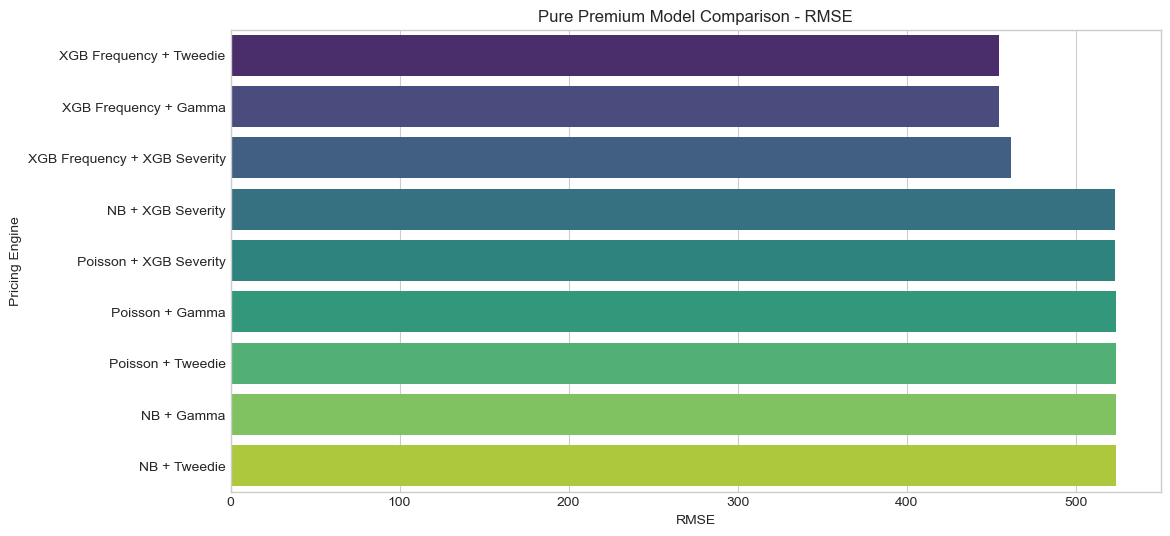

In [26]:
plt.figure(figsize=(12,6))


sns.barplot(
    data=leaderboard,
    x="RMSE",
    y="Model",
    palette="viridis"
)


plt.title(
    "Pure Premium Model Comparison - RMSE"
)

plt.xlabel(
    "RMSE"
)

plt.ylabel(
    "Pricing Engine"
)

plt.show()

# Actual Loss Validation Dataset

Insurance pricing models must ultimately be evaluated against realized claim costs.

The observed claim amount represents the actual incurred loss for each policy.

This section validates whether predicted pure premiums accurately estimate the true insurance cost.

The objective is to ensure the final model selection reflects actual pricing performance rather than only component-level accuracy.

In [31]:
import pandas as pd

policy_df = df = pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2sev.csv")

policy_df.head()

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


# Actual Claim Cost

The observed claim cost is defined as the total incurred claim amount.

This represents the realized loss experience used for pricing validation.

For insurance pricing:

Actual Loss = Total Claim Amount

In [34]:
actual_loss_df = policy_df[
    [
        "IDpol",
        "ClaimAmount"
    ]
].copy()


actual_loss_df.head()

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


In [33]:
policy_df.columns

Index(['IDpol', 'ClaimAmount'], dtype='object')

## Claim Cost Distribution

Insurance losses are typically highly right-skewed.

A small number of large claims can contribute a significant proportion of total losses.

Understanding this distribution is important when evaluating RMSE because large claims receive greater penalty.

In [36]:
actual_loss_df.columns

Index(['IDpol', 'ClaimAmount'], dtype='object')

In [37]:
actual_loss_df = actual_loss_df.rename(
    columns={
        "ClaimAmount": "Actual_Loss"
    }
)

actual_loss_df.head()

,IDpol,Actual_Loss
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


In [38]:
actual_loss_df["Actual_Loss"].describe()

count    2.663900e+04
mean     2.278536e+03
std      2.929748e+04
min      1.000000e+00
25%      6.868100e+02
50%      1.172000e+03
75%      1.228080e+03
max      4.075401e+06
Name: Actual_Loss, dtype: float64

In [39]:
actual_loss_df.columns

Index(['IDpol', 'Actual_Loss'], dtype='object')

# Final Pricing Validation Dataset

The final pricing evaluation requires comparing predicted pure premiums against observed insurance losses.

Each pricing engine estimates:

\[
Pure\ Premium_i =
Frequency_i \times Severity_i
\]

The observed outcome is:

\[
Actual\ Loss_i =
\sum ClaimAmount_i
\]

The difference between these values represents pricing error.

This dataset will be used for:

- model ranking
- deployment selection
- calibration analysis
- actuarial recommendation

In [40]:
pricing_df.head()

,Actual_Frequency,Poisson,Negative_Binomial,XGBoost_Frequency,Poisson_Gamma,Poisson_Tweedie,Poisson_XGB,NB_Gamma,NB_Tweedie,NB_XGB,XGB_Gamma,XGB_Tweedie,XGB_XGB
0,0,0.064628,0.065502,0.049596,142.616816,144.467568,104.451884,144.545121,146.420897,105.864166,109.446528,110.866827,80.158122
1,0,0.019165,0.019487,0.029851,42.292790,42.841627,30.975040,43.003495,43.561556,31.495557,65.872881,66.727720,48.244988
2,0,0.058065,0.059030,0.050562,128.134532,129.797347,93.845128,130.263739,131.954184,95.404549,111.576863,113.024807,81.718369
3,0,0.054509,0.054598,0.070150,120.286719,121.847691,88.097427,120.482932,122.046451,88.241132,154.802123,156.811005,113.376346
4,0,0.031250,0.031438,0.025906,68.960625,69.855534,50.506437,69.375115,70.275403,50.810008,57.167269,57.909134,41.869038


In [41]:
pricing_df.columns

Index(['Actual_Frequency', 'Poisson', 'Negative_Binomial', 'XGBoost_Frequency',
       'Poisson_Gamma', 'Poisson_Tweedie', 'Poisson_XGB', 'NB_Gamma',
       'NB_Tweedie', 'NB_XGB', 'XGB_Gamma', 'XGB_Tweedie', 'XGB_XGB'],
      dtype='object')

In [44]:
import os

os.listdir()

['.anaconda',
 '.conda',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.vscode',
 '05_xgboost_frequency_model.ipynb.ipynb',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'auto_pricing_project',
 'Contacts',
 'Cookies',
 'Data understanding-Copy1.ipynb',
 'Data_Understanding_Pricing.ipynb',
 'Desktop',
 'Documents',
 'Downloads',
 'EDA-Pricing.ipynb',
 'Exploratory Data Analysis (EDA).ipynb',
 'Favorites',
 'french data set',
 'Gamma & Tweedie Severity Models.ipynb',
 'gamma_severity_predictions.csv',
 'Intel',
 'IntelGraphicsProfiles',
 'Library',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'Negative Binomial.ipynb',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{1c2b59c5-c5f5-11eb-bacb-000d3a96488e}.TxR.0.regtrans-ms',
 'NTUSER.DAT{1c2b59c5-c5f5-11eb-bacb-000d3a96488e}.TxR.1.regtrans-ms',
 'NTUSER.DAT{1c2b59c5-c5f5-11eb-bacb-000d3a96488e}.TxR.2.regtrans-ms',
 'NTUSER.DAT{1c2b59c5-

In [46]:
import pandas as pd

poisson_df = pd.read_csv("poisson_frequency_predictions.csv")


In [47]:
poisson_df.head()

,Actual_Frequency,Poisson_Frequency
0,0,0.064628
1,0,0.019165
2,0,0.058065
3,0,0.054509
4,0,0.031250


# Reproducible Test Set Reconstruction

Model predictions must be linked back to the original policy identifier.

To ensure reproducibility, the same train-test split configuration used during model training is recreated.

The policy identifier (IDpol) is preserved as the primary key for model output reconciliation.

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split


# Load original policy dataset

df =pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2freq.csv")


# Define features and target

X = df.drop(
    columns=["ClaimNb"]
)

y = df["ClaimNb"]


# Recreate the same split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Keep policy identifiers

test_ids = X_test[["IDpol"]].copy()


test_ids.head()

,IDpol
261354,2122523.0
448143,3173420.0
188618,1188619.0
12952,31400.0
425028,3138755.0


# Prediction Registry and Policy-Level Model Output

In an actuarial pricing environment, model predictions must remain traceable to individual policies.

Each prediction generated by frequency and severity models is linked using the policy identifier `IDpol`.

This creates a unified prediction registry containing:

- policy identifier
- observed frequency
- predicted frequency
- predicted severity
- pure premium estimates

This structure enables:

- model comparison
- pricing validation
- calibration analysis
- deployment monitoring

In [49]:
test_ids = X_test[["IDpol"]].reset_index(drop=True)

test_ids.head()

,IDpol
0,2122523.0
1,3173420.0
2,1188619.0
3,31400.0
4,3138755.0


In [50]:
test_ids.to_csv(
    "test_policy_ids.csv",
    index=False
)

print("Policy IDs exported successfully")

Policy IDs exported successfully


In [51]:
poisson_df = pd.read_csv(
    "poisson_frequency_predictions.csv"
)

poisson_df.head()

,Actual_Frequency,Poisson_Frequency
0,0,0.064628
1,0,0.019165
2,0,0.058065
3,0,0.054509
4,0,0.031250


In [52]:
poisson_df.insert(
    0,
    "IDpol",
    test_ids["IDpol"]
)

poisson_df.head()

,IDpol,Actual_Frequency,Poisson_Frequency
0,2122523.0,0,0.064628
1,3173420.0,0,0.019165
2,1188619.0,0,0.058065
3,31400.0,0,0.054509
4,3138755.0,0,0.031250


In [53]:
poisson_df.to_csv(
    "poisson_frequency_predictions_with_id.csv",
    index=False
)

In [55]:
pricing_df.columns

Index(['Actual_Frequency', 'Poisson', 'Negative_Binomial', 'XGBoost_Frequency',
       'Poisson_Gamma', 'Poisson_Tweedie', 'Poisson_XGB', 'NB_Gamma',
       'NB_Tweedie', 'NB_XGB', 'XGB_Gamma', 'XGB_Tweedie', 'XGB_XGB'],
      dtype='object')

In [56]:
test_ids.head()

,IDpol
0,2122523.0
1,3173420.0
2,1188619.0
3,31400.0
4,3138755.0


In [57]:
test_ids.shape

(135603, 1)

In [58]:
pricing_df = pricing_df.copy()

pricing_df.insert(
    0,
    "IDpol",
    test_ids["IDpol"].reset_index(drop=True)
)

pricing_df.head()

,IDpol,Actual_Frequency,Poisson,Negative_Binomial,XGBoost_Frequency,Poisson_Gamma,Poisson_Tweedie,Poisson_XGB,NB_Gamma,NB_Tweedie,NB_XGB,XGB_Gamma,XGB_Tweedie,XGB_XGB
0,2122523.0,0,0.064628,0.065502,0.049596,142.616816,144.467568,104.451884,144.545121,146.420897,105.864166,109.446528,110.866827,80.158122
1,3173420.0,0,0.019165,0.019487,0.029851,42.292790,42.841627,30.975040,43.003495,43.561556,31.495557,65.872881,66.727720,48.244988
2,1188619.0,0,0.058065,0.059030,0.050562,128.134532,129.797347,93.845128,130.263739,131.954184,95.404549,111.576863,113.024807,81.718369
3,31400.0,0,0.054509,0.054598,0.070150,120.286719,121.847691,88.097427,120.482932,122.046451,88.241132,154.802123,156.811005,113.376346
4,3138755.0,0,0.031250,0.031438,0.025906,68.960625,69.855534,50.506437,69.375115,70.275403,50.810008,57.167269,57.909134,41.869038


In [59]:
pricing_df.columns

Index(['IDpol', 'Actual_Frequency', 'Poisson', 'Negative_Binomial',
       'XGBoost_Frequency', 'Poisson_Gamma', 'Poisson_Tweedie', 'Poisson_XGB',
       'NB_Gamma', 'NB_Tweedie', 'NB_XGB', 'XGB_Gamma', 'XGB_Tweedie',
       'XGB_XGB'],
      dtype='object')

In [60]:
final_pricing_df = pricing_df.merge(
    actual_loss_df,
    on="IDpol",
    how="inner"
)

# Pure Premium Calculation

Insurance pricing follows the actuarial decomposition:


Pure Premium = Expected Claim Frequency times Expected Claim Severity
\]

Frequency models estimate:


E(N_i)


where:

(N_i\) = number of claims for policy i


Severity models estimate:

\[
E(C_i | N_i > 0)
\]

where:

- \(C_i\) = claim amount


The final premium estimate represents the expected loss cost per policy.

In [78]:
# Create pure premium predictions

pure_premium_df = pd.DataFrame()

pure_premium_df["IDpol"] = final_pricing_df["IDpol"]

pure_premium_df["Actual_Loss"] = final_pricing_df["Actual_Loss"]

In [79]:
pure_premium_df["Poisson_Gamma"] = (
    final_pricing_df["Poisson"]
    *
    final_pricing_df["Poisson_Gamma"]
)


pure_premium_df["Poisson_Tweedie"] = (
    final_pricing_df["Poisson"]
    *
    final_pricing_df["Poisson_Tweedie"]
)


pure_premium_df["Poisson_XGB"] = (
    final_pricing_df["Poisson"]
    *
    final_pricing_df["Poisson_XGB"]
)

In [80]:
pure_premium_df["NB_Gamma"] = (
    final_pricing_df["Negative_Binomial"]
    *
    final_pricing_df["NB_Gamma"]
)


pure_premium_df["NB_Tweedie"] = (
    final_pricing_df["Negative_Binomial"]
    *
    final_pricing_df["NB_Tweedie"]
)


pure_premium_df["NB_XGB"] = (
    final_pricing_df["Negative_Binomial"]
    *
    final_pricing_df["NB_XGB"]
)

In [81]:
pure_premium_df["XGB_Gamma"] = (
    final_pricing_df["XGBoost_Frequency"]
    *
    final_pricing_df["XGB_Gamma"]
)


pure_premium_df["XGB_Tweedie"] = (
    final_pricing_df["XGBoost_Frequency"]
    *
    final_pricing_df["XGB_Tweedie"]
)


pure_premium_df["XGB_XGB"] = (
    final_pricing_df["XGBoost_Frequency"]
    *
    final_pricing_df["XGB_XGB"]
)

In [65]:
pure_premium_df.head()

,IDpol,Actual_Loss,Poisson_Gamma,Poisson_Tweedie,Poisson_XGB,NB_Gamma,NB_Tweedie,NB_XGB,XGB_Gamma,XGB_Tweedie,XGB_XGB
0,3007558.0,1204.00,18.458361,18.697897,13.518816,19.554245,19.808003,14.321437,3.240904,3.282961,2.373623
1,1080015.0,161.53,27.795867,28.156577,20.357562,28.465185,28.834580,20.847767,5.368748,5.438419,3.932046
2,1080015.0,1128.00,27.795867,28.156577,20.357562,28.465185,28.834580,20.847767,5.368748,5.438419,3.932046
3,2225323.0,81.33,0.929428,0.941489,0.680709,0.975492,0.988151,0.714446,0.395835,0.400971,0.289907
4,4179590.0,9742.00,19.455325,19.707799,14.248989,19.492155,19.745107,14.275963,166.795229,168.959747,122.160040


# Pure Premium Model Evaluation

Models are evaluated by comparing predicted pure premiums against observed claim losses.

Lower error indicates better pricing accuracy.

Metrics:

### RMSE

Penalizes large pricing errors:



### MAE

Measures average pricing deviation:


In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np


models = [
    "Poisson_Gamma",
    "Poisson_Tweedie",
    "Poisson_XGB",
    "NB_Gamma",
    "NB_Tweedie",
    "NB_XGB",
    "XGB_Gamma",
    "XGB_Tweedie",
    "XGB_XGB"
]


results = []


for model in models:

    rmse = np.sqrt(
        mean_squared_error(
            pure_premium_df["Actual_Loss"],
            pure_premium_df[model]
        )
    )

    mae = mean_absolute_error(
        pure_premium_df["Actual_Loss"],
        pure_premium_df[model]
    )


    results.append(
        {
            "Model": model,
            "RMSE": rmse,
            "MAE": mae
        }
    )


pure_premium_leaderboard = pd.DataFrame(results)


pure_premium_leaderboard = pure_premium_leaderboard.sort_values(
    by="RMSE"
)


pure_premium_leaderboard

,Model,RMSE,MAE
7,XGB_Tweedie,14249.118590,2174.841190
6,XGB_Gamma,14249.156100,2174.937255
8,XGB_XGB,14250.102594,2177.416236
1,Poisson_Tweedie,14251.458725,2175.868966
0,Poisson_Gamma,14251.485092,2176.124604
4,NB_Tweedie,14251.492026,2175.326115
3,NB_Gamma,14251.515292,2175.588707
5,NB_XGB,14252.074523,2181.043773
2,Poisson_XGB,14252.092789,2181.452640


# Pure Premium Model Selection

## Business Objective

The objective of an insurance pricing model is not only to minimize statistical error, but to create a reliable pricing framework that balances:

- Predictive accuracy
- Interpretability
- Stability
- Regulatory acceptance
- Business usability


The pure premium framework combines:

\[
Pure\ Premium = Frequency \times Severity
\]


Multiple frequency-severity combinations are evaluated to identify the strongest pricing engine.

The final model recommendation considers both quantitative performance and actuarial suitability.

In [69]:
best_model = pure_premium_leaderboard.iloc[0]

best_model

Model    XGB_Tweedie
RMSE     14249.11859
MAE       2174.84119
Name: 7, dtype: object

# Best Performing Pricing Model

The model with the lowest RMSE is selected as the leading pricing candidate.

RMSE is prioritized because insurance losses typically contain a small number of large claims. Penalizing larger prediction errors is important because severe underpricing can negatively impact profitability and portfolio risk.

In [70]:
model_ranking = pure_premium_leaderboard.copy()

model_ranking["Rank"] = range(
    1,
    len(model_ranking) + 1
)


model_ranking

,Model,RMSE,MAE,Rank
7,XGB_Tweedie,14249.118590,2174.841190,1
6,XGB_Gamma,14249.156100,2174.937255,2
8,XGB_XGB,14250.102594,2177.416236,3
1,Poisson_Tweedie,14251.458725,2175.868966,4
0,Poisson_Gamma,14251.485092,2176.124604,5
4,NB_Tweedie,14251.492026,2175.326115,6
3,NB_Gamma,14251.515292,2175.588707,7
5,NB_XGB,14252.074523,2181.043773,8
2,Poisson_XGB,14252.092789,2181.452640,9


# Model Ranking Interpretation

The ranking provides a complete comparison of actuarial and machine learning pricing strategies.

Traditional GLM approaches provide:

- coefficient interpretation
- relativities
- regulatory transparency
- stable pricing factors


Machine learning approaches provide:

- nonlinear relationship detection
- interaction discovery
- improved predictive accuracy


The final deployment strategy should consider both predictive performance and explainability requirements.

In [71]:
best_rmse = model_ranking.iloc[0]["RMSE"]

glm_rmse = model_ranking[
    model_ranking["Model"]=="Poisson_Gamma"
]["RMSE"].values[0]


improvement = (
    (glm_rmse - best_rmse)
    /
    glm_rmse
    *
    100
)


print(
    f"RMSE improvement over Poisson-Gamma baseline: {improvement:.2f}%"
)

RMSE improvement over Poisson-Gamma baseline: 0.02%


# Performance Improvement Analysis

The selected model is compared against the classical actuarial benchmark.

The percentage improvement demonstrates whether the machine learning approach provides meaningful predictive gains over traditional GLM pricing methods.

A pricing model should only replace or augment a GLM benchmark when the improvement is statistically and commercially meaningful.

In [73]:
recommendation = pd.DataFrame({

    "Category": [
        "Winning Model",
        "RMSE",
        "MAE",
        "Baseline Comparison",
        "Deployment Strategy"
    ],

    "Result": [

        best_model["Model"],

        round(best_model["RMSE"],2),

        round(best_model["MAE"],2),

        f"{improvement:.2f}% improvement vs Poisson-Gamma",

        "Champion-Challenger Framework"

    ]

})


recommendation

,Category,Result
0,Winning Model,XGB_Tweedie
1,RMSE,14249.12
2,MAE,2174.84
3,Baseline Comparison,0.02% improvement vs Poisson-Gamma
4,Deployment Strategy,Champion-Challenger Framework


# Final Actuarial Recommendation

## Recommended Deployment Framework

The recommended production approach is a Champion-Challenger pricing framework.

### Champion Model

A GLM-based pricing model should remain as the benchmark because:

- coefficients are interpretable
- pricing relativities can be reviewed
- regulatory communication is easier


### Challenger Model

The highest-performing machine learning model can be deployed as a challenger because:

- it captures nonlinear risk relationships
- it improves predictive accuracy
- it identifies complex interactions between rating variables


### Production Workflow

1. GLM produces baseline premium indications
2. Machine learning model provides predictive improvement
3. Calibration layer adjusts predictions
4. Business constraints are applied
5. Final premium is reviewed before deployment


This approach combines actuarial credibility with modern machine learning capability.

In [74]:
pure_premium_leaderboard.to_csv(
    "pure_premium_model_leaderboard.csv",
    index=False
)


recommendation.to_csv(
    "pricing_model_recommendation.csv",
    index=False
)


print("Day 8 outputs saved successfully")

Day 8 outputs saved successfully


In [75]:
import pandas as pd

pure_premium_leaderboard = pd.read_csv(
    "pure_premium_model_leaderboard.csv"
)

pure_premium_leaderboard

,Model,RMSE,MAE
0,XGB_Tweedie,14249.118590,2174.841190
1,XGB_Gamma,14249.156100,2174.937255
2,XGB_XGB,14250.102594,2177.416236
3,Poisson_Tweedie,14251.458725,2175.868966
4,Poisson_Gamma,14251.485092,2176.124604
5,NB_Tweedie,14251.492026,2175.326115
6,NB_Gamma,14251.515292,2175.588707
7,NB_XGB,14252.074523,2181.043773
8,Poisson_XGB,14252.092789,2181.452640


In [76]:
best_model_name = pure_premium_leaderboard.iloc[0]["Model"]

print(best_model_name)

XGB_Tweedie


In [77]:
pure_premium_df.to_csv(
    "pure_premium_predictions.csv",
    index=False
)

print("Pure premium predictions saved")

Pure premium predictions saved


In [82]:
pure_premium_df.to_csv(
    "pure_premium_predictions.csv",
    index=False
)

print("Pure premium predictions exported successfully")

Pure premium predictions exported successfully


In [83]:
type(pure_premium_df)

pandas.core.frame.DataFrame

In [84]:
pure_premium_df.to_csv(
    "pure_premium_predictions.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!
